For this lab, we will be using the following libraries:

* [`crewai`](https://docs.crewai.com/introduction) for creating AI Agents and orchestrating workflows.
* [`crewai_tools`](https://docs.crewai.com/core-concepts/Tools/) to equip our AI Agents with powerful pre-built tools.
* [`langchain-community`](https://python.langchain.com/docs/integrations/tools/) for additional community-provided tools.
* [`langchain-huggingface`](https://python.langchain.com/docs/integrations/providers/huggingface/) to power our PDF searching tool.
* [`sentence-transformers`](https://python.langchain.com/docs/integrations/text_embedding/sentence_transformers/) as the embedding model for our PDF searching tool.


### Installing Required Libraries

Installing the libraries might take a few minutes. If you find any pip dependency errors, simply restart the kernel by going to `Kernel -> Restart Kernel` and execute the next cell (not the one below).


In [8]:
%%capture
%pip install crewai==0.186.1
%pip install crewai-tools==0.71.0
%pip install langchain-community==0.3.29
%pip install langchain-huggingface==0.3.1
%pip install sentence-transformers==5.1.0
%pip install litellm

In [9]:
%pip install pywin32

Note: you may need to restart the kernel to use updated packages.


In [10]:
%%capture

from crewai import Agent, Task, Crew, Process
from crewai import LLM
from crewai_tools import PDFSearchTool, SerperDevTool

In [11]:
import litellm
litellm.ssl_verify = False

### Agentic AI with CrewAI

At a high level, instead of designing complex, rigid code for this chatbot, we delegate the work to a team—or **Crew**—of AI Agents.

An **AI Agent** is an autonomous worker. Like any worker, it needs a clear job description, which we provide through specific parameters:
- **Role:** What is its primary function? (for example, "Customer Service Specialist")
- **Goal:** What is it trying to achieve? (for example, "Answer customer questions accurately")
- **Backstory:** What context does it need to perform its role effectively?
- **Tools:** What resources can it use to accomplish its goal? (for example, a PDF search tool, a web browser)

Once we have our agents, we define the **Tasks** they need to complete. A **Crew** then orchestrates this entire process, managing the agents and ensuring tasks are executed in the correct order to achieve the final objective.


### The Role of Tools: Agent-Centric versus Task-Centric

A key decision in CrewAI is *how* to give tools to your agents. There are two main strategies, and understanding the difference is crucial for building robust applications.

**1. Agent-Centric Approach (The Generalist):**
This is the most common method. You give an agent a 'toolbox' containing all the tools it might possibly need. The agent then uses its intelligence (the LLM's reasoning ability) to decide which tool is best for the situation at hand. This is flexible but can sometimes lead to the agent making mistakes or using tools inefficiently.
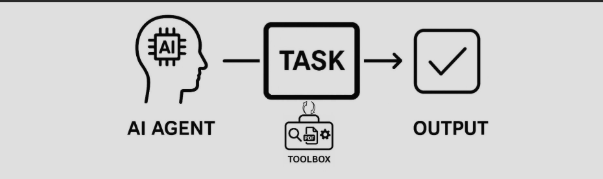

**2. Task-Centric Approach (The Specialist):**
In this more advanced approach, you don't give the tools to the agent directly. Instead, you attach specific tools to the specific **Tasks** that require them. When the agent starts a task, it is temporarily granted access to only the tools needed for that job. This creates a much more focused and predictable workflow.

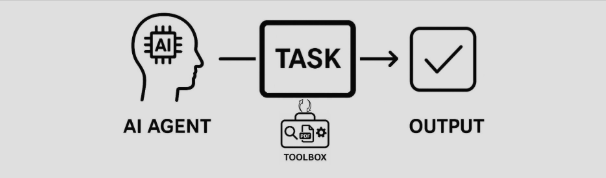

### Configuring our LLM

First, we configure the Language Model (LLM) that will power our agents' reasoning and language generation. We're using IBM's WatsonX `Granite 3.3` model. Although other models could be used, this one provides a good balance of performance and cost for our use case.


In [12]:
%pip install ollama

Note: you may need to restart the kernel to use updated packages.


In [ ]:
from crewai import Agent, Crew, Process, Task, LLM

# in local command prompt type 'ollama run gemma4' without quotes and then browse to http://localhost:11434  in browser to make sure it loads

# 1. Define the local Ollama LLM configuration
llm = LLM(
    model="ollama/gemma4",
    base_url="http://localhost:11434"
)

### Defining Tools for Information Gathering

Our chatbot needs to access information from two sources: Daily Dish's FAQ PDF and the general internet. To do this, we'll instantiate two tools.

1.  **`PDFSearchTool`**: This tool, from the `crewai_tools` library, will index the provided PDF document. When used, it performs a semantic search to find the most relevant sections of the PDF related to a query.
2.  **`SerperDevTool`**: This simple tool from `crewai_tools` allows an agent to perform a web search using SerperAPI.


To use `SerperDevTool`, we first need an **API key**—a crucial credential that grants access to web searches. Once we have the API key, we can import the library and integrate it into our customer service workflow.  

> You will need to get the API Key from `serper.dev` website. To get the API key, create an account using your email if you have registered or login if you already have an account. Once you are logged in, you will be on the `Dashboard` section. Click on `API Keys` and you will find your API key. Copy the key and replace it with `API_KEY` here.

To get the API key and for more details on `SerperDevTool` and its capabilities, visit the official webpage: [SerperDevTool Documentation](https://serper.dev/).


In [14]:
import os
from crewai_tools import SerperDevTool

os.environ['SERPER_API_KEY'] = '230509b2410851769a2515878d4e1c71fd2f8bf8'
web_search_tool = SerperDevTool() 

In [15]:
import warnings
from crewai_tools import PDFSearchTool

warnings.filterwarnings('ignore') #Keeps Jupyter Notebook clean (not part of functionality)

pdf_search_tool = PDFSearchTool(
    pdf="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/7vgNfis17dQfjHAiIKkBOg/The-Daily-Dish-FAQ.pdf",
    config=dict(
        embedder=dict(
            provider="huggingface",
            config=dict(
                model="sentence-transformers/all-MiniLM-L6-v2"
            )
        )
    )
)

2026-09-19 10:26:37,755 - 30416 - _utils.py-_utils:460 - WARNING: Ignoring wrong pointing object 89 0 (offset 0)


### Approach 1: The Standard Method (Agent-Centric Tools)

First, we'll build the chatbot using the conventional approach where we give our agent a toolbox with all the necessary tools. The agent will be responsible for deciding whether to search the PDF or generate a response with just it's LLM.

#### **Step 1.1: Create the Agent**

We define an `Inquiry Specialist Agent` whose job is to answer questions. Notice that the `tools` parameter is a list containing the `pdf_search_tool` and `web_search_tool`.


In [16]:
agent_centric_agent = Agent(
    role="The Daily Dish Inquiry Specialist",
    goal="""Accurately answer customer questions about The Daily Dish restaurant. 
    You must decide whether to use the restaurant's FAQ PDF or a web search to find the best answer.""",
    backstory="""You are an AI assistant for 'The Daily Dish'.
    You have access to two tools: one for searching the restaurant's FAQ document and another for searching the web.
    Your job is to analyze the user's question and choose the most appropriate tool to find the information needed to provide a helpful response.""",
    tools=[pdf_search_tool, web_search_tool],
    verbose=True,
    allow_delegation=False,
    llm=llm
)

NameError: name 'llm' is not defined

In [ ]:
agent_centric_task = Task(
    description="Answer the following customer query: '{customer_query}'. "
                "Analyze the question and use the tools at your disposal (PDF search or web search) to find the most relevant information. "
                "Synthesize the findings into a clear and friendly response.",
    expected_output="A comprehensive and well-formatted answer to the customer's query.",
    agent=agent_centric_agent
)

NameError: name 'agent_centric_agent' is not defined

In [ ]:
agent_centric_crew = Crew(
    agents=[agent_centric_agent],
    tasks=[agent_centric_task],
    process=Process.sequential,
    verbose=False
)